# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kiran162005/flyrank-ml/blob/main/work/notebooks/capstone.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

### Research Question

**Can observable webpage search and engagement signals be used to prioritize webpages for content review?**

The goal is to help an SEO/content team decide **which webpages should be reviewed first** when working with a large number of webpages.

The system supports a prioritization decision:

* **REVIEW** — highest priority for human review
* **WATCH** — monitor for potential opportunity
* **NO_ACTION** — no immediate priority from the current rule

The unit of analysis is an individual webpage identified using pseudonymized client and content identifiers.

The system is designed as **decision support**, not as an autonomous content-editing system. It identifies observed performance patterns that may deserve investigation; it does not determine that a webpage is objectively poor or that refreshing it will improve search performance.


## 2. Data

The analysis uses the **FlyRank ML Internship dataset**.

The primary development table is:

`fact_content_daily_performance`

The daily data contains webpage-level search and analytics observations for clients and report dates.

### Development Window

* Development period: **March 2026**
* Original grain: **client × webpage × report date**
* Modeling grain: **client × webpage**
* Search metrics were restricted to records where GSC data was available.

### Main Observable Signals

The workflow uses observable performance signals including:

* GSC impressions
* GSC clicks
* GSC average position
* GA4 pageviews
* GA4 sessions
* GA4 users
* CTR for descriptive analysis and baseline scoring

The large daily dataset was aggregated before being converted to a pandas DataFrame to reduce memory usage.

### Exclusions

The public workflow excludes:

* client names
* domains
* webpage URLs
* private search queries
* identifying webpage text
* credentials and authentication information
* future outcome fields when they could leak the target
* product decision/health flags
* other identifying business information

Pseudonymized identifiers and aggregate performance measurements are used instead.

### Public-Safety Principle

The paper reports aggregate statistics, methodology, model results, and generic examples. It does not expose private client information or search-query data.


## 3. Methodology

### Features

The final leakage-audited model feature set consists of:

* `impressions`
* `clicks`
* `avg_position`
* `pageviews`
* `sessions`
* `users`

These represent observable information available at the modeling decision point.

### Target

The modeling task predicts whether a webpage experiences a future decline relative to its current observed performance.

The intended structure is:

**current/historical features → decision point → future outcome → target**

Separating the feature window from the future outcome is important for avoiding target leakage.

### Model

The learned model is **Logistic Regression**.

Logistic Regression was selected because it is simple, computationally efficient, suitable for binary classification, and easier to interpret than a more complex model.

### Transparent Baseline

The Week-4 baseline uses simple observable rules:

| Condition                  | Score | Reason                | Action    |
| -------------------------- | ----: | --------------------- | --------- |
| High impressions + low CTR |     2 | `LOW_CTR_HIGH_VOLUME` | REVIEW    |
| High impressions           |     1 | `HIGH_SEARCH_VOLUME`  | WATCH     |
| Otherwise                  |     0 | `LOW_PRIORITY`        | NO_ACTION |

The baseline provides a transparent reference against which the learned model can be evaluated.

### Validation

The learned model uses grouped validation based on `client_hash_id`.

This prevents the same client from appearing in both the training and validation groups, reducing the risk that client-specific patterns inflate the evaluation.

### Primary Metric

The primary evaluation metric is **F1 score**, because the task requires balancing precision and recall when prioritizing potential review opportunities.

Additional metrics are:

* Accuracy
* Precision
* Recall
* ROC-AUC

### Leakage Check

The final feature list was checked against known target, future, and decision fields.

The audit confirms:

**PASS — no known target/flag/future fields are in the feature list.**

An important lesson from development was that a target must not be directly constructed from the same current variables supplied to the model. Doing so can create artificially perfect results without demonstrating genuine predictive ability.


In [1]:
# Final leakage audit

FINAL_FEATURES = [
    "impressions",
    "clicks",
    "avg_position",
    "pageviews",
    "sessions",
    "users"
]

FORBIDDEN_FIELDS = {
    "trend_direction",
    "trend_pct",
    "future_impressions",
    "future_clicks",
    "future_ctr",
    "target_decline"
}

leakage_hits = set(FINAL_FEATURES).intersection(FORBIDDEN_FIELDS)

if leakage_hits:
    print("FAIL — forbidden target/future fields found:", leakage_hits)
else:
    print("PASS — no known target/flag/future fields are in the feature list.")

PASS — no known target/flag/future fields are in the feature list.


## 4. Results (vs baseline)

The learned Logistic Regression model was compared with the transparent Week-4 baseline on the same modeling task.

| Model               |  Accuracy | Precision |    Recall |        F1 |   ROC-AUC |
| ------------------- | --------: | --------: | --------: | --------: | --------: |
| Logistic Regression | **0.888** | **0.710** | **0.903** | **0.795** | **0.948** |
| Week-4 Baseline     |     0.666 |     0.403 |     0.796 |     0.535 |     0.948 |

### Main Result

The Logistic Regression model achieved an **F1 score of 0.795**, compared with **0.535** for the transparent baseline.

This is an absolute F1 improvement of approximately **0.260**.

The learned model also achieved higher precision and recall:

* Precision: 0.710 vs 0.403
* Recall: 0.903 vs 0.796
* F1: 0.795 vs 0.535

The result indicates that combining multiple observable signals can provide stronger predictive separation than the simple baseline rule in this development evaluation.

However, this result should be interpreted only within the evaluated validation setting. It does not establish that the model will perform equally well on every future client or time period.


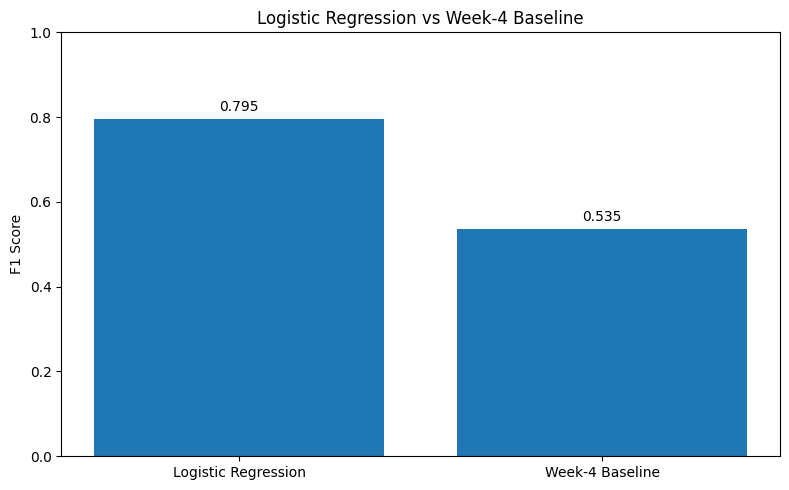

In [2]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Week-4 Baseline"]
f1_scores = [0.794943, 0.535401]

plt.figure(figsize=(8, 5))
plt.bar(models, f1_scores)

plt.ylabel("F1 Score")
plt.title("Logistic Regression vs Week-4 Baseline")
plt.ylim(0, 1)

for i, value in enumerate(f1_scores):
    plt.text(i, value + 0.02, f"{value:.3f}", ha="center")

plt.tight_layout()
plt.show()

## 5. Limitations

This analysis has several important limitations.

### Observational Data

The dataset contains observed search and engagement behavior rather than randomized experimental data.

Therefore, the model does not establish causality.

In particular, the analysis cannot prove that refreshing a recommended webpage will improve SEO performance.

### Limited Time Window

The development analysis uses a defined period of data. Search behavior can change across time, industries, seasons, and external events.

Additional future validation periods are needed to establish temporal robustness.

### Client Differences

Clients can differ in site structure, audience, content strategy, industry, and search behavior.

Grouped validation reduces client overlap between training and validation, but it does not guarantee equal performance on every unseen client.

### Feature Limitations

The model uses aggregate performance signals and does not directly understand:

* search intent
* content quality
* competitor content
* SERP features
* title quality
* internal linking
* backlinks
* business priorities

### Target Limitation

The decline target is an operational outcome definition, not a direct measurement of content quality.

A webpage can experience declining search performance for reasons unrelated to content freshness or quality.

### Honest Claim

The strongest supported conclusion is:

**The workflow can rank observed webpage-performance patterns for content-review prioritization, and the learned model outperformed the transparent baseline on F1 in the evaluated development setting.**

It does not prove which webpages should definitely be refreshed, predict Google's ranking algorithm, or guarantee improved performance after a content change.


## 6. Ranked Recommendations

The action playbook converts observed performance signals into a human-review queue.

### Priority 1 — REVIEW

**Reason code:** `LOW_CTR_HIGH_VOLUME`

Pages with substantial search exposure and relatively low CTR receive the highest priority for human investigation.

Reviewers should examine:

* search intent
* ranking position
* SERP context
* title/snippet relevance
* content freshness
* query mix
* recent page changes
* business relevance
* expected effort versus potential value

The signal indicates that a page deserves investigation; it does not prove that the page needs a refresh.

### Priority 2 — WATCH

**Reason code:** `HIGH_SEARCH_VOLUME`

Pages with meaningful search exposure but without the stronger low-CTR condition can be monitored for future changes.

### Priority 3 — NO_ACTION

**Reason code:** `LOW_PRIORITY`

Pages that do not meet the current priority conditions receive no immediate recommendation from this baseline.

This does not mean that these pages are permanently healthy or should never be reviewed.

### Human-in-the-Loop Principle

The system recommends **where to look**, not **what to publish**.

A human SEO/content specialist remains responsible for deciding whether a page should actually be changed.

The system must not automatically rewrite, publish, delete, redirect, merge, or otherwise modify webpages.


## 7. Artifacts the Paper Embeds

The capstone is supported by the following analysis artifacts.

### Leakage Audit

Confirms that the final model feature list does not contain explicit target, future, or decision fields.

### Signal Audit

Documents the distribution and behavior of the main observable search-performance signals.

### Transparent Baseline

Provides the interpretable high-volume/low-CTR rule used as the comparison baseline.

### Learned Model

The Logistic Regression model provides the learned classification approach used in the final model comparison.

### Validation Audit

Documents grouped validation, leakage controls, failure cases, and the limits of the resulting claims.

### Action Playbook

The Week-7 export contains the ranked action queue with pseudonymized identifiers, aggregate performance metrics, scores, actions, and reason codes.

The final action queue contains **176,738 webpage-level rows**:

| Action    |        Rows |
| --------- | ----------: |
| REVIEW    |     100,660 |
| NO_ACTION |      75,297 |
| WATCH     |         781 |
| **Total** | **176,738** |

The queue is intended for human review and prioritization rather than automatic content changes.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.